<a href="https://colab.research.google.com/github/mohalifal9/Assignment3_6022251082/blob/main/Assignment_3_Moh_Alif_Abdul_Latif_6022251082.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# =======================================================
# 1. PARAMETER SINGLETON OUTPUT (SUGENO 0-ORDE)
# =======================================================
# Harga Paket (z) dalam satuan Juta Rupiah
z_basic = 15
z_premium = 30
z_platinum = 50

In [14]:
# =======================================================
# 2. FUNGSI KEANGGOTAAN INPUT 1: LUAS AREA PV (0 - 100 m2)
# =======================================================
def fuzzify_luas(x):
    # Sedikit
    if x <= 20: luas_sedikit = 1.0
    elif 20 < x <= 50: luas_sedikit = (50 - x) / (50 - 20)
    else: luas_sedikit = 0.0

    # Sedang
    if 20 < x <= 50: luas_sedang = (x - 20) / (50 - 20)
    elif 50 < x <= 80: luas_sedang = (80 - x) / (80 - 50)
    else: luas_sedang = 0.0

    # Banyak
    if 50 < x <= 80: luas_banyak = (x - 50) / (80 - 50)
    elif x > 80: luas_banyak = 1.0
    else: luas_banyak = 0.0

    return luas_sedikit, luas_sedang, luas_banyak

In [15]:
# =======================================================
# 3. FUNGSI KEANGGOTAAN INPUT 2: DAYA (0 - 10.000 Watt)
# =======================================================
def fuzzify_daya(x):
    # Kecil
    if x <= 2000: daya_kecil = 1.0
    elif 2000 < x <= 5000: daya_kecil = (5000 - x) / (5000 - 2000)
    else: daya_kecil = 0.0

    # Menengah
    if 2000 < x <= 5000: daya_menengah = (x - 2000) / (5000 - 2000)
    elif 5000 < x <= 8000: daya_menengah = (8000 - x) / (8000 - 5000)
    else: daya_menengah = 0.0

    # Besar
    if 5000 < x <= 8000: daya_besar = (x - 5000) / (8000 - 5000)
    elif x > 8000: daya_besar = 1.0
    else: daya_besar = 0.0

    return daya_kecil, daya_menengah, daya_besar

In [16]:
# =======================================================
# 4. SIMULASI FIS SUGENO 0-ORDE
# =======================================================
def fis_sugeno_pv(input_luas, input_daya):
    print(f"Input: Luas PV = {input_luas} m2 | Daya = {input_daya} Watt")

    # Tahap 1: Fuzzifikasi
    l_sedikit, l_sedang, l_banyak = fuzzify_luas(input_luas)
    d_kecil, d_menengah, d_besar = fuzzify_daya(input_daya)

    # Tahap 2: Inference (Evaluasi Aturan)
    f1 = min(l_sedikit, d_kecil)     ; z1 = z_basic
    f2 = min(l_sedikit, d_menengah)  ; z2 = z_basic
    f3 = min(l_sedikit, d_besar)     ; z3 = z_premium  # <-- Aturan Wajib
    f4 = min(l_sedang, d_kecil)      ; z4 = z_basic
    f5 = min(l_sedang, d_menengah)   ; z5 = z_premium
    f6 = min(l_sedang, d_besar)      ; z6 = z_platinum
    f7 = min(l_banyak, d_kecil)      ; z7 = z_premium
    f8 = min(l_banyak, d_menengah)   ; z8 = z_platinum
    f9 = min(l_banyak, d_besar)      ; z9 = z_platinum

    # Tahap 3: Defuzzifikasi Weighted Average
    pembilang = (f1*z1) + (f2*z2) + (f3*z3) + (f4*z4) + (f5*z5) + (f6*z6) + (f7*z7) + (f8*z8) + (f9*z9)
    penyebut = f1 + f2 + f3 + f4 + f5 + f6 + f7 + f8 + f9

    if penyebut == 0:
        z_final = 0
    else:
        z_final = pembilang / penyebut

    # Menentukan Nama Paket
    if round(z_final, 1) == z_basic:
        nama_paket = "PAKET BASIC"
    elif round(z_final, 1) == z_premium:
        nama_paket = "PAKET PREMIUM"
    elif round(z_final, 1) == z_platinum:
        nama_paket = "PAKET PLATINUM"
    elif z_basic < z_final < z_premium:
        if z_final >= ((z_basic + z_premium) / 2):
            nama_paket = "Kustomisasi (Condong ke PREMIUM)"
        else:
            nama_paket = "Kustomisasi (Condong ke BASIC)"
    elif z_premium < z_final < z_platinum:
        if z_final >= ((z_premium + z_platinum) / 2):
            nama_paket = "Kustomisasi (Condong ke PLATINUM)"
        else:
            nama_paket = "Kustomisasi (Condong ke PREMIUM)"
    else:
        nama_paket = "Di Luar Kategori"

    print(f"Rekomendasi Harga (Z*) : Rp {z_final:.2f} Juta")
    print(f"Rekomendasi Paket      : {nama_paket}")
    print(f"--------------------------------------------------")

    return z_final

In [23]:
# =======================================================
# 5. JALANKAN SKENARIO UJI COBA
# =======================================================
print("==================================================")
print("     SIMULASI SISTEM PAKAR FIS SUGENO")
print("==================================================\n")

print(">>> SKENARIO 1: Lahan Sempit & Daya Ekstra Besar (Aturan Wajib)")
fis_sugeno_pv(input_luas=15, input_daya=9000)

print(">>> SKENARIO 2: Kondisi Standar Perumahan")
fis_sugeno_pv(input_luas=45, input_daya=3500)

print(">>> SKENARIO 3: Lahan Sangat Luas & Daya Kecil")
fis_sugeno_pv(input_luas=85, input_daya=1500)

     SIMULASI SISTEM PAKAR FIS SUGENO

>>> SKENARIO 1: Lahan Sempit & Daya Ekstra Besar (Aturan Wajib)
Input: Luas PV = 15 m2 | Daya = 9000 Watt
Rekomendasi Harga (Z*) : Rp 30.00 Juta
Rekomendasi Paket      : PAKET PREMIUM
--------------------------------------------------
>>> SKENARIO 2: Kondisi Standar Perumahan
Input: Luas PV = 45 m2 | Daya = 3500 Watt
Rekomendasi Harga (Z*) : Rp 20.62 Juta
Rekomendasi Paket      : Kustomisasi (Condong ke BASIC)
--------------------------------------------------
>>> SKENARIO 3: Lahan Sangat Luas & Daya Kecil
Input: Luas PV = 85 m2 | Daya = 1500 Watt
Rekomendasi Harga (Z*) : Rp 30.00 Juta
Rekomendasi Paket      : PAKET PREMIUM
--------------------------------------------------


30.0

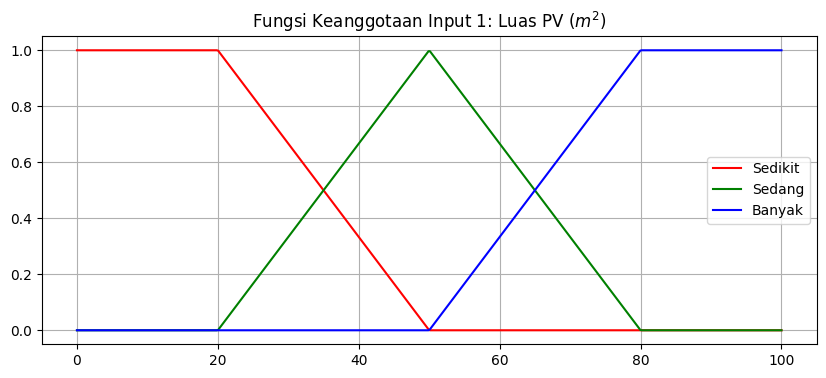

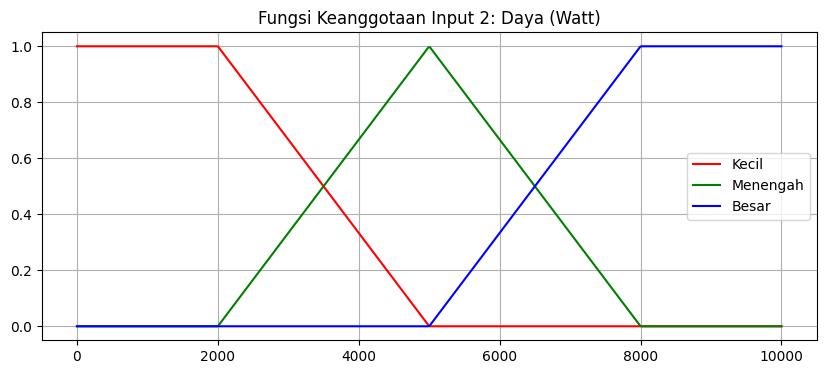

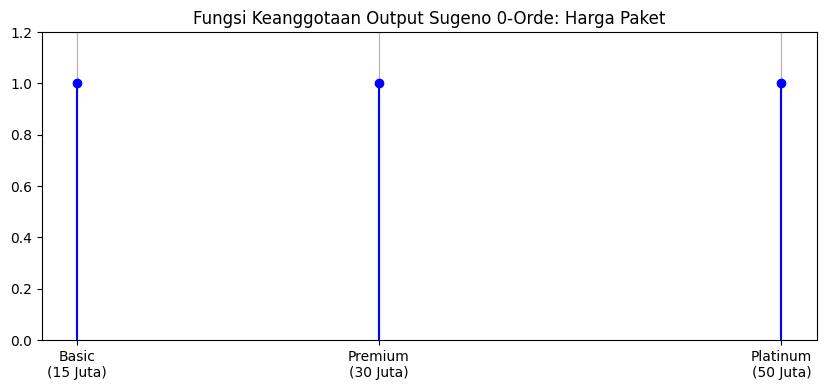

In [18]:
# =======================================================
# 6. VISUALISASI GRAFIK
# =======================================================
# Membuat array data X
x_luas = np.linspace(0, 100, 500)
x_daya = np.linspace(0, 10000, 500)

# Menghitung Y untuk setiap X
y_luas_sedikit, y_luas_sedang, y_luas_banyak = np.zeros_like(x_luas), np.zeros_like(x_luas), np.zeros_like(x_luas)
for i, x in enumerate(x_luas):
    y_luas_sedikit[i], y_luas_sedang[i], y_luas_banyak[i] = fuzzify_luas(x)

y_daya_kecil, y_daya_menengah, y_daya_besar = np.zeros_like(x_daya), np.zeros_like(x_daya), np.zeros_like(x_daya)
for i, x in enumerate(x_daya):
    y_daya_kecil[i], y_daya_menengah[i], y_daya_besar[i] = fuzzify_daya(x)

# 1. Plot Input Luas PV
plt.figure(figsize=(10, 4))
plt.plot(x_luas, y_luas_sedikit, 'r', label='Sedikit')
plt.plot(x_luas, y_luas_sedang, 'g', label='Sedang')
plt.plot(x_luas, y_luas_banyak, 'b', label='Banyak')
plt.title('Fungsi Keanggotaan Input 1: Luas PV ($m^2$)')
plt.legend()
plt.grid(True)
plt.savefig('grafik_luas.png')
plt.show()

# 2. Plot Input Daya
plt.figure(figsize=(10, 4))
plt.plot(x_daya, y_daya_kecil, 'r', label='Kecil')
plt.plot(x_daya, y_daya_menengah, 'g', label='Menengah')
plt.plot(x_daya, y_daya_besar, 'b', label='Besar')
plt.title('Fungsi Keanggotaan Input 2: Daya (Watt)')
plt.legend()
plt.grid(True)
plt.savefig('grafik_daya.png')
plt.show()

# 3. Plot Output Harga (Singleton Sugeno)
plt.figure(figsize=(10, 4))
plt.stem([z_basic, z_premium, z_platinum], [1, 1, 1], basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xticks([z_basic, z_premium, z_platinum], ['Basic\n(15 Juta)', 'Premium\n(30 Juta)', 'Platinum\n(50 Juta)'])
plt.title('Fungsi Keanggotaan Output Sugeno 0-Orde: Harga Paket')
plt.ylim(0, 1.2)
plt.grid(True, axis='x')
plt.savefig('grafik_harga.png')
plt.show()